# Inventory Analysis

ABC/XYZ segmentation for inventory optimization, demand volatility analysis, product profitability, and stockout risk assessment.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


In [2]:
df = pd.read_csv('../data/supply_chain_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (180519, 62)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,order_year,order_month,order_day,order_dayofweek,order_quarter,order_hour,is_weekend,shipping_year,shipping_month,actual_shipping_delay,is_early_or_ontime,order_to_shipping_hours,order_season
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,1,22,0,2018,2,-1.00,1,72.00,Winter
1,TRANSFER,5,4,-79.70,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-79.70,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,1,12,1,2018,1,1.00,0,120.00,Winter


=== ABC Classification (by Sales) ===
  A: 6 products, $25,384,501 sales, 219,888 units
  B: 4 products, $7,712,834 sales, 112,226 units
  C: 108 products, $3,687,400 sales, 51,965 units


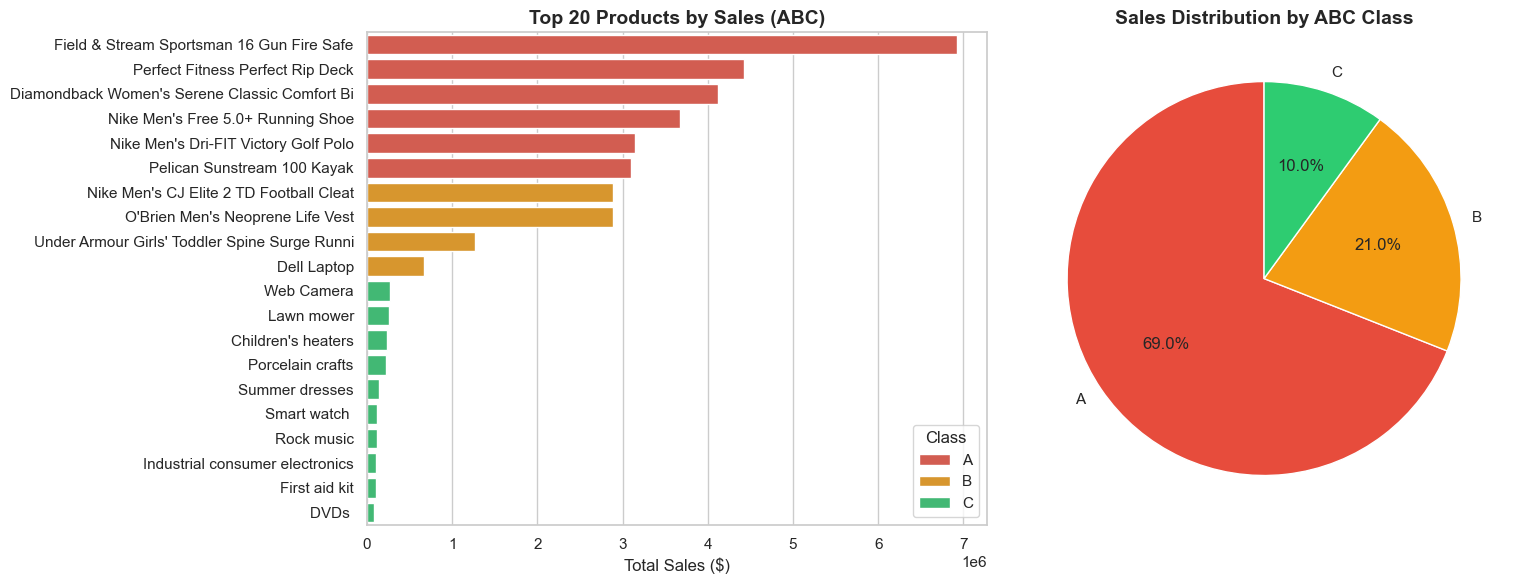

In [3]:
# === ABC Analysis: Product Revenue Contribution ===
prod_sales = df.groupby('product_name').agg(
    total_sales=('sales', 'sum'),
    total_quantity=('order_item_quantity', 'sum'),
    total_profit=('order_profit_per_order', 'sum'),
    order_count=('order_id', 'nunique')
).sort_values('total_sales', ascending=False).reset_index()

prod_sales['cumulative_pct'] = prod_sales['total_sales'].cumsum() / prod_sales['total_sales'].sum() * 100

def abc_classify(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

prod_sales['abc_class'] = prod_sales['cumulative_pct'].apply(abc_classify)

abc_counts = prod_sales['abc_class'].value_counts().sort_index()
print('=== ABC Classification (by Sales) ===')
for cls in ['A', 'B', 'C']:
    subset = prod_sales[prod_sales['abc_class'] == cls]
    print(f"  {cls}: {len(subset)} products, "
          f"${subset['total_sales'].sum():,.0f} sales, "
          f"{subset['total_quantity'].sum():,} units")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'A': '#e74c3c', 'B': '#f39c12', 'C': '#2ecc71'}
sns.barplot(data=prod_sales.head(20), x='total_sales', y='product_name',
            hue='abc_class', palette=colors, dodge=False, ax=axes[0])
axes[0].set_title('Top 20 Products by Sales (ABC)')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('')
axes[0].legend(title='Class')

abc_summary = prod_sales.groupby('abc_class').agg(
    products=('product_name', 'size'),
    total_sales=('total_sales', 'sum'),
    total_profit=('total_profit', 'sum')
)
axes[1].pie(abc_summary['total_sales'], labels=abc_summary.index,
            autopct='%1.1f%%', colors=[colors[c] for c in abc_summary.index],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Sales Distribution by ABC Class')

save_fig('15_abc_analysis')
plt.show()


=== Category-Level ABC ===


,category_name,abc_class,total_sales,total_profit,products
0,Fishing,A,"6,929,653.69","1,209,264.95",1
1,Cleats,A,"4,431,942.78","724,975.74",2
2,Camping & Hiking,A,"4,118,425.57","712,464.78",1
3,Cardio Equipment,A,"3,694,843.20","610,068.74",2
4,Women's Apparel,A,"3,147,800.00","497,804.64",1
5,Water Sports,A,"3,113,844.68","502,913.18",2
6,Men's Footwear,B,"2,891,757.66","422,611.65",1
7,Indoor/Outdoor Games,B,"2,888,993.91","451,951.90",1
8,Shop By Sport,B,"1,309,522.04","183,242.97",3
9,Computers,C,"663,000.00","46,811.58",1


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_26597/1694087231.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='total_sales', y='category_name', palette=palette, ax=ax)


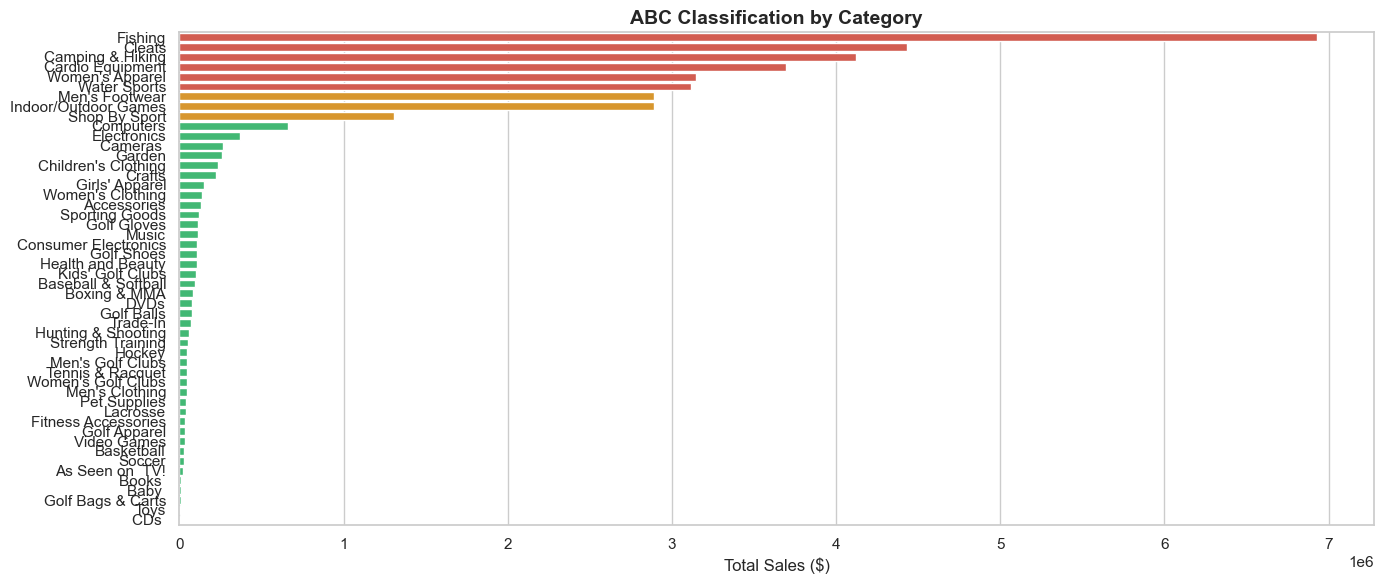

In [4]:
# === Category-Level ABC ===
cat_sales = df.groupby('category_name').agg(
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum'),
    total_quantity=('order_item_quantity', 'sum'),
    products=('product_name', 'nunique')
).sort_values('total_sales', ascending=False).reset_index()

cat_sales['cumulative_pct'] = cat_sales['total_sales'].cumsum() / cat_sales['total_sales'].sum() * 100
cat_sales['abc_class'] = cat_sales['cumulative_pct'].apply(abc_classify)

print('=== Category-Level ABC ===')
display(cat_sales[['category_name', 'abc_class', 'total_sales', 'total_profit', 'products']])

fig, ax = plt.subplots(figsize=(14, 6))
palette = [colors[c] for c in cat_sales['abc_class']]
sns.barplot(data=cat_sales, x='total_sales', y='category_name', palette=palette, ax=ax)
ax.set_title('ABC Classification by Category')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('')
save_fig('16_abc_category')
plt.show()


=== XYZ Classification (Demand Volatility) ===
  X: 115 products (CV <= 0.5)
  Y: 3 products (CV <= 1.0)
  Z: 0 products (CV <= >1.0)


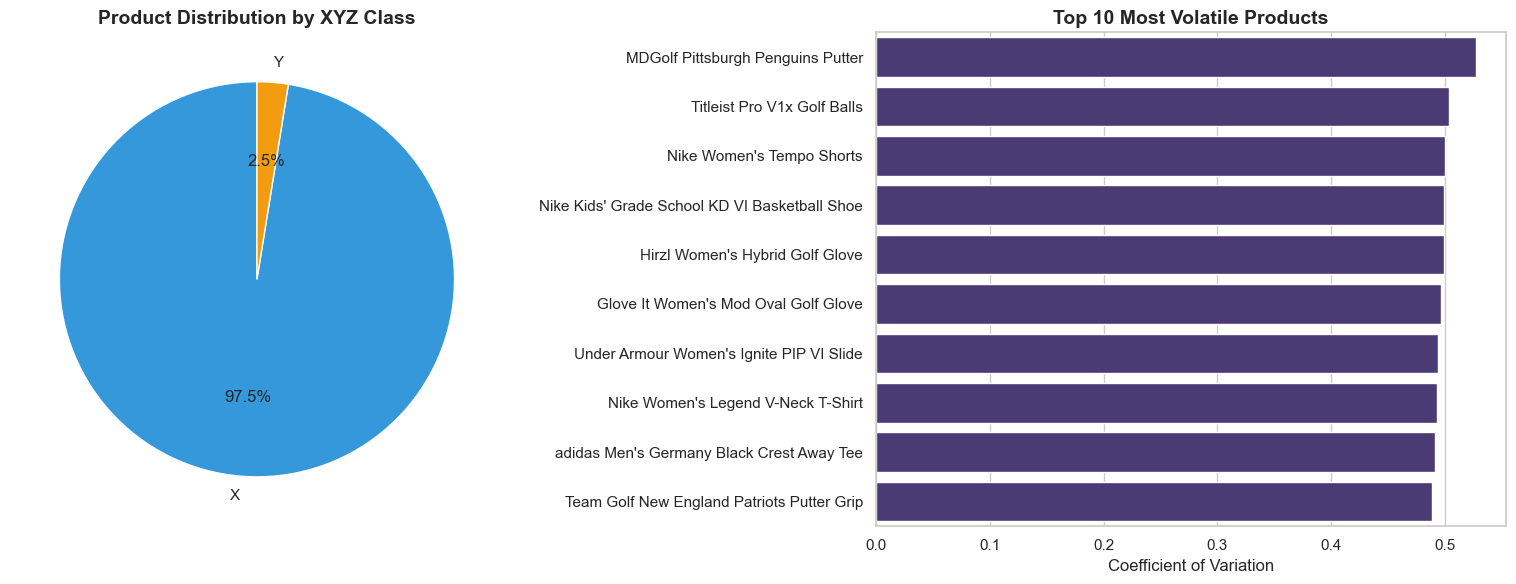

In [5]:
# === XYZ Analysis: Demand Volatility ===
prod_vol = df.groupby('product_name').agg(
    total_quantity=('order_item_quantity', 'sum'),
    order_count=('order_id', 'nunique'),
    std_quantity=('order_item_quantity', 'std'),
    mean_quantity=('order_item_quantity', 'mean')
).reset_index()

prod_vol['cv'] = prod_vol['std_quantity'] / prod_vol['mean_quantity'].replace(0, np.nan)

def xyz_classify(cv):
    if pd.isna(cv):
        return 'Z'
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

prod_vol['xyz_class'] = prod_vol['cv'].apply(xyz_classify)
xyz_counts = prod_vol['xyz_class'].value_counts().sort_index()

print('=== XYZ Classification (Demand Volatility) ===')
for cls in ['X', 'Y', 'Z']:
    subset = prod_vol[prod_vol['xyz_class'] == cls]
    print(f"  {cls}: {len(subset)} products (CV <= {'0.5' if cls=='X' else '1.0' if cls=='Y' else '>1.0'})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
xyz_colors = {'X': '#3498db', 'Y': '#f39c12', 'Z': '#e74c3c'}
axes[0].pie(xyz_counts, labels=xyz_counts.index, autopct='%1.1f%%',
            colors=[xyz_colors[c] for c in xyz_counts.index],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Product Distribution by XYZ Class')

top_volatile = prod_vol.nlargest(10, 'cv')
sns.barplot(data=top_volatile, x='cv', y='product_name', ax=axes[1])
axes[1].set_title('Top 10 Most Volatile Products')
axes[1].set_xlabel('Coefficient of Variation')
axes[1].set_ylabel('')

save_fig('17_xyz_analysis')
plt.show()


=== ABC-XYZ Matrix (Product Count) ===


xyz_class,X,Y
abc_class,,
A,6,0
B,4,0
C,105,3



=== ABC-XYZ Matrix (Row % within ABC Class) ===


xyz_class,X,Y
abc_class,,
A,100.00,0.00
B,100.00,0.00
C,97.20,2.80


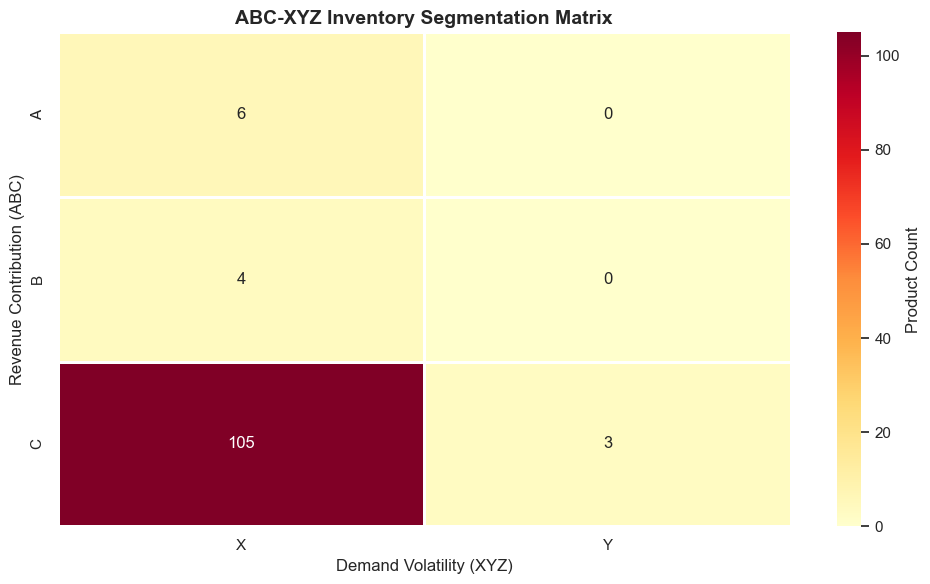

In [6]:
# === ABC-XYZ Matrix ===
merged = prod_sales.merge(prod_vol[['product_name', 'xyz_class']], on='product_name')
matrix = pd.crosstab(merged['abc_class'], merged['xyz_class'])
matrix_pct = pd.crosstab(merged['abc_class'], merged['xyz_class'], normalize='index') * 100

print('=== ABC-XYZ Matrix (Product Count) ===')
display(matrix)
print('\n=== ABC-XYZ Matrix (Row % within ABC Class) ===')
display(matrix_pct.round(1))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, ax=ax, cbar_kws={'label': 'Product Count'})
ax.set_title('ABC-XYZ Inventory Segmentation Matrix')
ax.set_xlabel('Demand Volatility (XYZ)')
ax.set_ylabel('Revenue Contribution (ABC)')
save_fig('18_abc_xyz_matrix')
plt.show()


=== Order Status Breakdown ===


,orders,total_sales,total_profit
order_status,,,
COMPLETE,59491,"12,095,314.95","1,952,346.72"
PENDING_PAYMENT,39832,"8,106,697.56","1,303,970.33"
PROCESSING,21902,"4,504,063.75","729,530.54"
PENDING,20227,"4,120,532.87","656,729.66"
CLOSED,19616,"4,022,624.17","662,629.33"
ON_HOLD,9804,"1,981,542.71","311,508.59"
SUSPECTED_FRAUD,4062,"825,934.96","129,847.44"
CANCELED,3692,"744,370.40","121,292.98"
PAYMENT_REVIEW,1893,"383,653.66","61,630.09"



=== Lost Orders Impact ===
Lost orders: 7,754 (4.3%)
Lost sales value: $1,570,305 (4.3% of total)


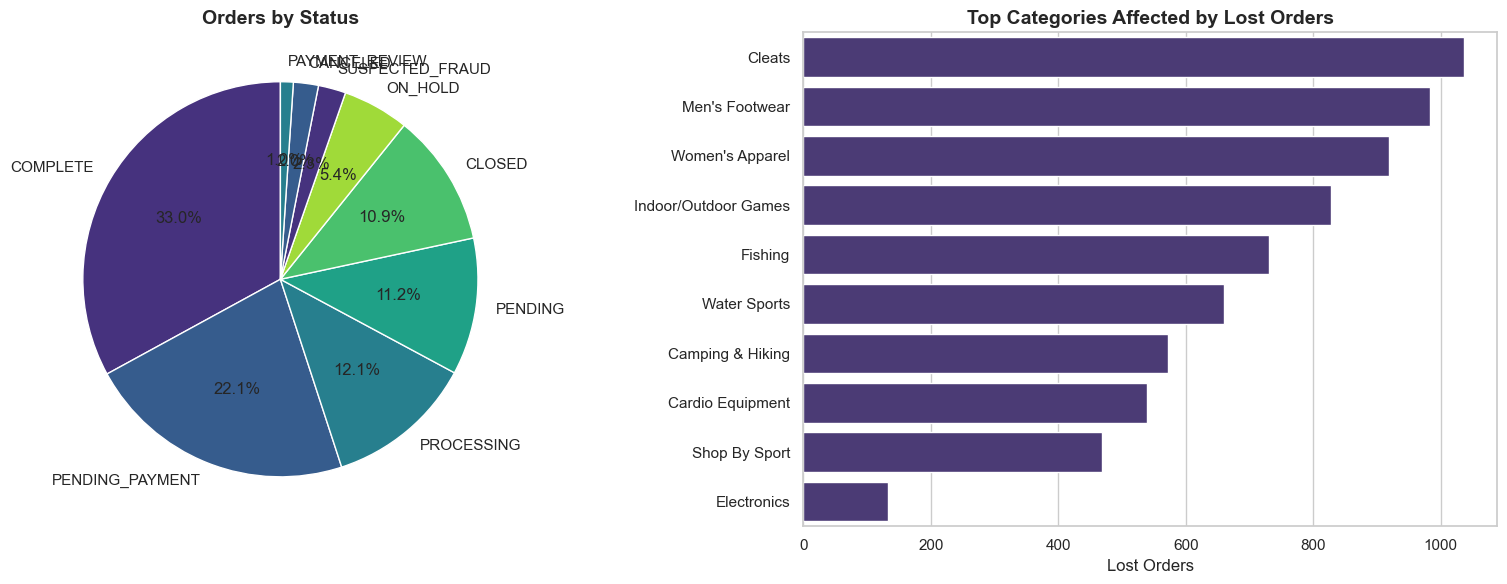

In [7]:
# === Order Status Analysis ===
status_counts = df['order_status'].value_counts()
status_sales = df.groupby('order_status').agg(
    orders=('order_id', 'size'),
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum')
).sort_values('orders', ascending=False)

print('=== Order Status Breakdown ===')
display(status_sales)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Orders by Status')

lost_statuses = ['CANCELED', 'SUSPECTED_FRAUD']
lost = df[df['order_status'].isin(lost_statuses)]
lost_value = lost['sales'].sum()
lost_count = len(lost)
total_sales = df['sales'].sum()
print(f'\n=== Lost Orders Impact ===')
print(f'Lost orders: {lost_count:,} ({lost_count/len(df)*100:.1f}%)')
print(f'Lost sales value: ${lost_value:,.0f} ({lost_value/total_sales*100:.1f}% of total)')

cat_lost = lost.groupby('category_name').agg(
    lost_orders=('order_id', 'size'),
    lost_sales=('sales', 'sum')
).sort_values('lost_orders', ascending=False).head(10)
axes[1] = sns.barplot(data=cat_lost.reset_index(), y='category_name', x='lost_orders', ax=axes[1])
axes[1].set_title('Top Categories Affected by Lost Orders')
axes[1].set_xlabel('Lost Orders')
axes[1].set_ylabel('')

save_fig('19_order_status')
plt.show()


=== Department Profitability ===

,total_sales,total_profit,orders,avg_margin
department_name,,,,
Fan Shop,"17,113,870.94","2,885,062.20",66861,0.12
Apparel,"7,976,255.34","1,258,741.17",48998,0.12
Golf,"4,609,028.24","703,943.15",33220,0.12
Footwear,"4,006,498.77","654,326.13",14525,0.12
Outdoors,"1,253,351.45","193,673.13",9686,0.13
Technology,"1,039,598.97","111,360.97",1465,0.13
Fitness,"397,050.89","66,729.89",2479,0.13
Discs Shop,"228,887.73","33,908.40",2026,0.11
Health and Beauty,"106,080.48","16,262.94",362,0.10


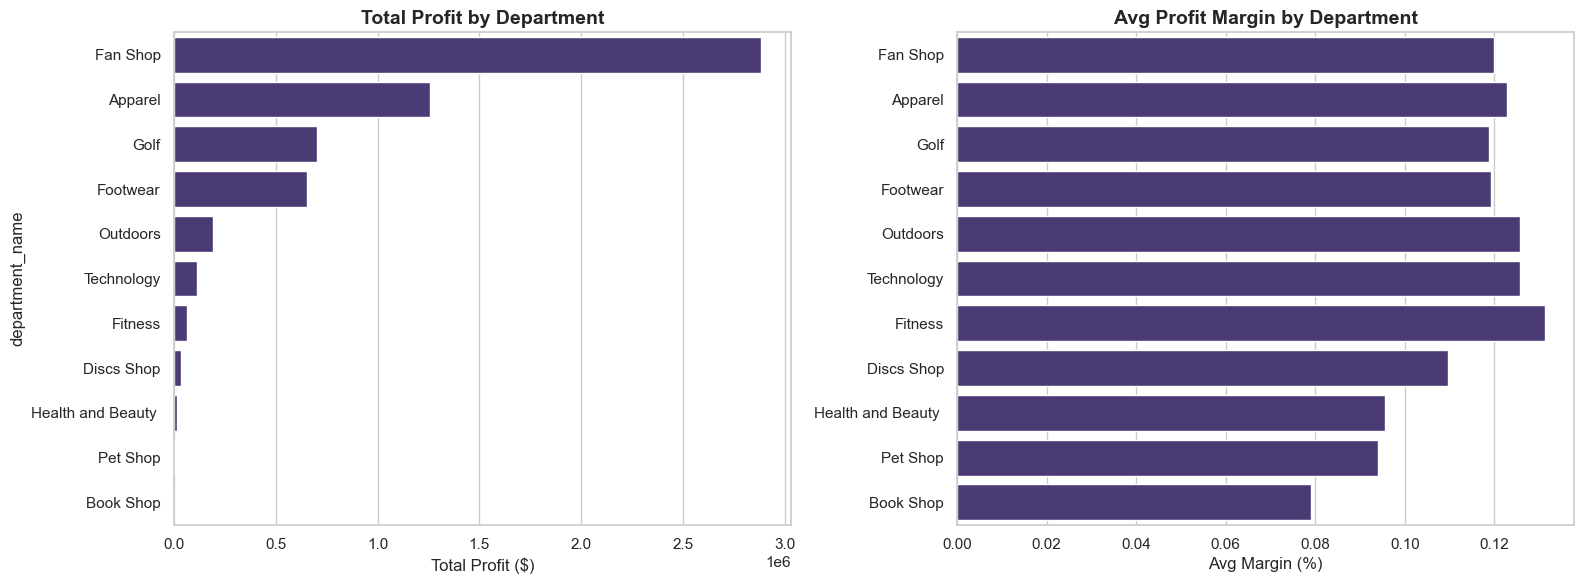

In [8]:
# === Department & Category Profitability ===
dept_profit = df.groupby('department_name').agg(
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum'),
    orders=('order_id', 'size'),
    avg_margin=('order_item_profit_ratio', 'mean')
).sort_values('total_profit', ascending=False)

print('=== Department Profitability ===')
display(dept_profit.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=dept_profit.reset_index(), x='total_profit', y='department_name', ax=axes[0])
axes[0].set_title('Total Profit by Department')
axes[0].set_xlabel('Total Profit ($)')

sns.barplot(data=dept_profit.reset_index(), x='avg_margin', y='department_name', ax=axes[1])
axes[1].set_title('Avg Profit Margin by Department')
axes[1].set_xlabel('Avg Margin (%)')
axes[1].set_ylabel('')

save_fig('20_dept_profitability')
plt.show()


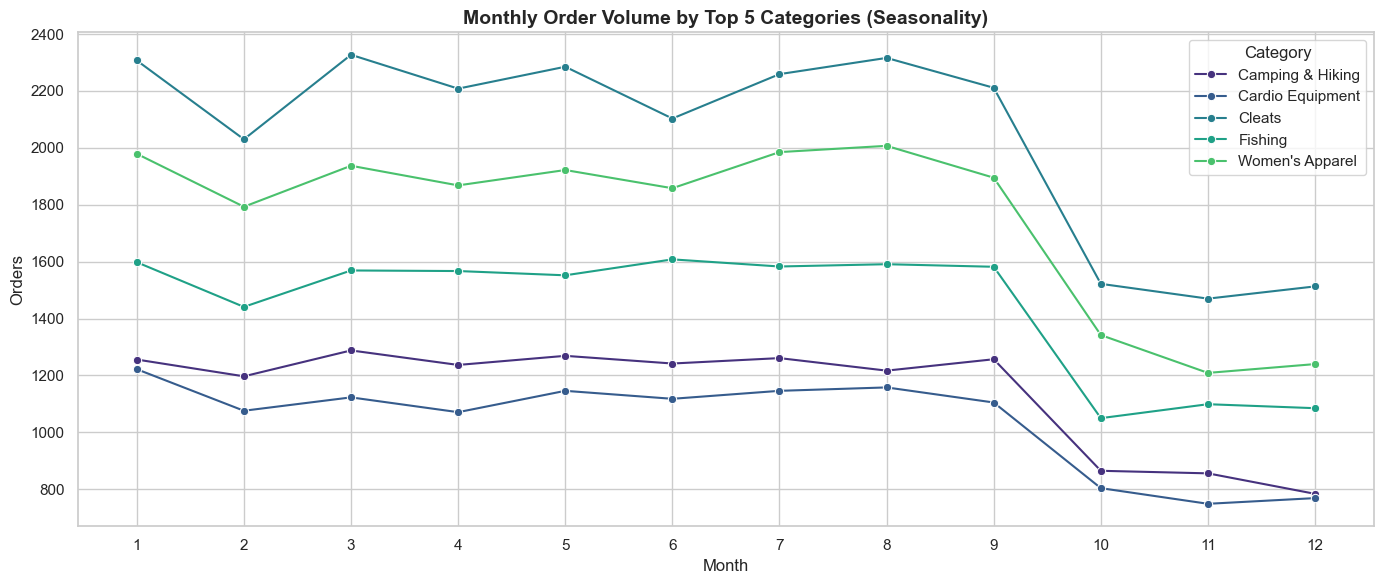

=== Peak Month by Category ===


,category_name,order_month,sales,orders
80,Cleats,3,"418,190.30",2327
269,Men's Footwear,8,"271,809.10",2091
359,Women's Apparel,8,"296,400.00",2007
229,Indoor/Outdoor Games,1,"274,540.14",1827
117,Fishing,6,"643,167.86",1608
344,Water Sports,5,"299,185.05",1496
54,Camping & Hiking,3,"386,374.25",1288
64,Cardio Equipment,1,"355,524.81",1222
287,Shop By Sport,3,"123,839.85",1037
338,Video Games,1,"24,247.50",610


In [9]:
# === Seasonal Demand by Category (C3) ===
df['order_month'] = pd.to_datetime(df['order_date_dateorders']).dt.month
monthly_cat = df.groupby(['category_name', 'order_month']).agg(
    sales=('sales', 'sum'),
    orders=('order_id', 'size')
).reset_index()

top_cats = df.groupby('category_name')['sales'].sum().nlargest(5).index
monthly_top = monthly_cat[monthly_cat['category_name'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_top, x='order_month', y='orders',
             hue='category_name', marker='o', ax=ax)
ax.set_title('Monthly Order Volume by Top 5 Categories (Seasonality)')
ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.legend(title='Category')
ax.set_xticks(range(1, 13))
save_fig('21_seasonal_demand')
plt.show()

print('=== Peak Month by Category ===')
peak_month = monthly_cat.loc[monthly_cat.groupby('category_name')['orders'].idxmax()]
display(peak_month.sort_values('orders', ascending=False).head(10))


=== Order Quantity Stats ===
count   180,519.00
mean          2.13
std           1.45
min           1.00
25%           1.00
50%           1.00
75%           3.00
max           5.00
Name: order_item_quantity, dtype: float64


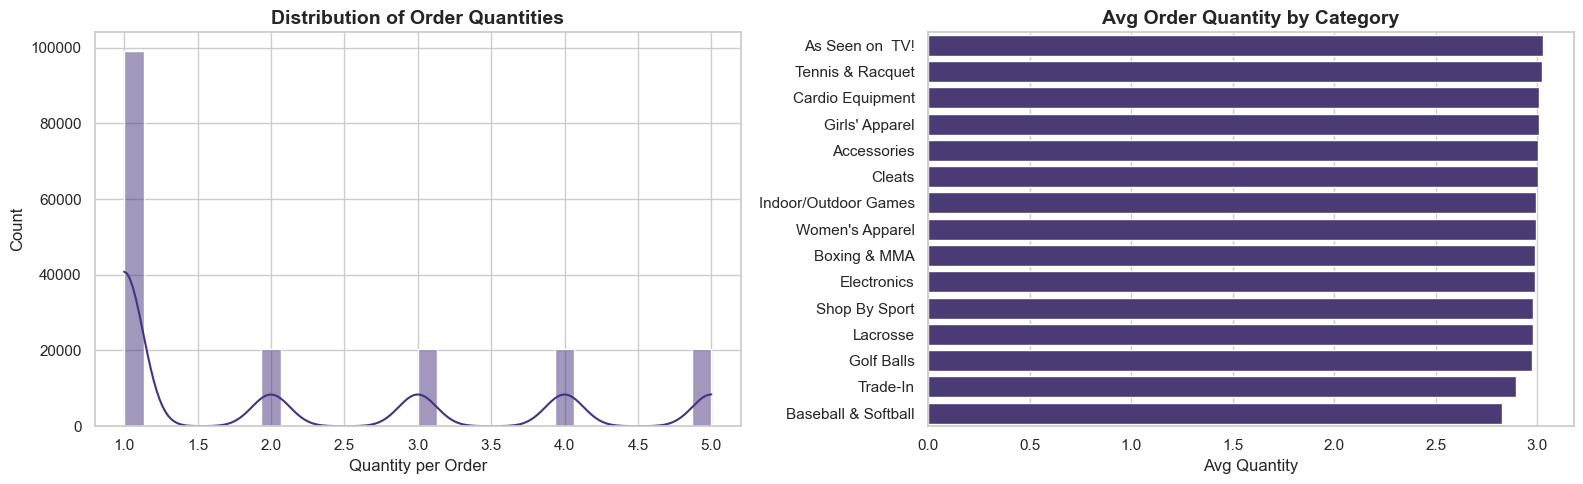

In [10]:
# === Order Quantity Distribution ===
print('=== Order Quantity Stats ===')
print(df['order_item_quantity'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['order_item_quantity'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Order Quantities')
axes[0].set_xlabel('Quantity per Order')

qty_cat = df.groupby('category_name')['order_item_quantity'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=qty_cat.values, y=qty_cat.index, ax=axes[1])
axes[1].set_title('Avg Order Quantity by Category')
axes[1].set_xlabel('Avg Quantity')
axes[1].set_ylabel('')

save_fig('22_quantity_distribution')
plt.show()


In [11]:
# === Inventory Turnover Estimate (A5) ===
# Note: True inventory turnover requires stock-on-hand data, which this dataset lacks.
# We calculate COGS proxy and sell-through rate as alternatives.

# COGS proxy = sales × (1 - profit_ratio) aggregated
# profit_ratio = order_profit_per_order / sales (approximately)
cogs_proxy = (df['sales'] - df['order_profit_per_order']).sum()
total_sales = df['sales'].sum()
avg_margin = df['order_profit_per_order'].sum() / df['sales'].sum()

# Total units sold
total_units = df['order_item_quantity'].sum()
unique_products = df['product_name'].nunique()
avg_price = df['order_item_product_price'].mean()

# Annualized metrics (2015-2018 = 3 years of data, actually ~3 years)
years = df['order_year'].nunique()
annual_sales = total_sales / years
annual_cogs = cogs_proxy / years

# Sell-through rate proxy: units sold per product per year
avg_units_per_product_per_year = total_units / unique_products / years

# Proxy inventory value (assuming 30-day stock coverage as industry standard)
daily_cogs = annual_cogs / 365
est_avg_inventory = daily_cogs * 30  # 30 days of COGS as avg inventory
est_turnover = annual_cogs / est_avg_inventory if est_avg_inventory > 0 else None

print('=' * 60)
print('INVENTORY TURNOVER ESTIMATE (A5)')
print('=' * 60)
print(f'Period: {years} years (2015-2018)')
print(f'Total sales: ${total_sales:,.2f}')
print(f'COGS proxy (sales - profit): ${cogs_proxy:,.2f}')
print(f'Average profit margin: {avg_margin:.2%}')
print(f'Total units sold: {total_units:,}')
print(f'Unique products: {unique_products}')
print(f'\nAnnualized metrics:')
print(f'  Annual sales: ${annual_sales:,.2f}')
print(f'  Annual COGS: ${annual_cogs:,.2f}')
print(f'  Avg units/product/year: {avg_units_per_product_per_year:.1f}')
print(f'\nEstimated Inventory Turnover (proxy):')
if est_turnover:
    print(f'  Est. avg inventory (30-day COGS): ${est_avg_inventory:,.2f}')
    print(f'  Est. turnover ratio: {est_turnover:.1f}x/year')
print(f'\n⚠️  LIMITATION: True turnover requires actual stock-on-hand data.')
print(f'   This estimate assumes 30-day average inventory coverage.')
print(f'   Without beginning/ending inventory values, this is directional only.')


INVENTORY TURNOVER ESTIMATE (A5)
Period: 4 years (2015-2018)
Total sales: $36,784,735.01
COGS proxy (sales - profit): $30,855,249.34
Average profit margin: 16.12%
Total units sold: 384,079
Unique products: 118

Annualized metrics:
  Annual sales: $9,196,183.75
  Annual COGS: $7,713,812.33
  Avg units/product/year: 813.7

Estimated Inventory Turnover (proxy):
  Est. avg inventory (30-day COGS): $634,011.97
  Est. turnover ratio: 12.2x/year

⚠️  LIMITATION: True turnover requires actual stock-on-hand data.
   This estimate assumes 30-day average inventory coverage.
   Without beginning/ending inventory values, this is directional only.


In [12]:
print('=' * 60)
print('INVENTORY ANALYSIS KEY FINDINGS')
print('=' * 60)

a_count = len(prod_sales[prod_sales['abc_class'] == 'A'])
b_count = len(prod_sales[prod_sales['abc_class'] == 'B'])
c_count = len(prod_sales[prod_sales['abc_class'] == 'C'])
print(f'\nABC: {a_count} A-items (70% revenue), {b_count} B-items (20%), {c_count} C-items (10%)')

x_count = len(prod_vol[prod_vol['xyz_class'] == 'X'])
y_count = len(prod_vol[prod_vol['xyz_class'] == 'Y'])
z_count = len(prod_vol[prod_vol['xyz_class'] == 'Z'])
print(f'XYZ: {x_count} X-items (stable), {y_count} Y-items (moderate), {z_count} Z-items (volatile)')

top_cat_name = dept_profit.index[0]
top_cat_profit = dept_profit.iloc[0]['total_profit']
print(f'\nMost profitable department: {top_cat_name} (${top_cat_profit:,.0f})')

lost_count = len(df[df['order_status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])])
lost_pct = lost_count / len(df) * 100
print(f'Lost/canceled orders: {lost_count:,} ({lost_pct:.1f}%)')

print(f'\nAll visuals saved to visuals/')


INVENTORY ANALYSIS KEY FINDINGS

ABC: 6 A-items (70% revenue), 4 B-items (20%), 108 C-items (10%)
XYZ: 115 X-items (stable), 3 Y-items (moderate), 0 Z-items (volatile)

Most profitable department: Fan Shop ($2,885,062)
Lost/canceled orders: 7,754 (4.3%)

All visuals saved to visuals/
